### **Necessary Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

### **Exploring The Dataset**

In [3]:
df = pd.read_csv("ecommerce_customer_behavior_dataset.csv")

In [4]:
df.head()

,Customer ID,Age,Gender,Location,Product Category,Purchase Amount ($),Time Spent on Website (min),Device Type,Payment Method,Discount Availed,Number of Items Purchased,Return Customer,Review Score (1-5),Delivery Time (days),Subscription Status,Customer Satisfaction
0,1,20,Other,Dhaka,Toys,202.54,44,Mobile,Cash on Delivery,True,4,True,5,4,Free,Low
1,2,39,Male,Rangpur,Sports,655.94,27,Desktop,Bank Transfer,True,1,False,1,7,Free,Medium
2,3,64,Male,Khulna,Home,963.65,9,Tablet,Bank Transfer,False,8,True,4,9,Premium,Medium
3,4,65,Other,Rajshahi,Beauty,485.59,39,Desktop,Bank Transfer,True,1,True,5,10,Trial,Medium
4,5,67,Male,Rangpur,Home,143.27,17,Tablet,Debit Card,False,8,True,4,1,Premium,High


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer ID                  10000 non-null  int64  
 1   Age                          10000 non-null  int64  
 2   Gender                       10000 non-null  str    
 3   Location                     10000 non-null  str    
 4   Product Category             10000 non-null  str    
 5   Purchase Amount ($)          10000 non-null  float64
 6   Time Spent on Website (min)  10000 non-null  int64  
 7   Device Type                  10000 non-null  str    
 8   Payment Method               10000 non-null  str    
 9   Discount Availed             10000 non-null  bool   
 10  Number of Items Purchased    10000 non-null  int64  
 11  Return Customer              10000 non-null  bool   
 12  Review Score (1-5)           10000 non-null  int64  
 13  Delivery Time (days)        

In [6]:
num_duplicates = df.duplicated().sum()
print(f"Total number of duplicate rows in the dataset: {num_duplicates}")

Total number of duplicate rows in the dataset: 0


In [7]:
df.describe()

,Customer ID,Age,Purchase Amount ($),Time Spent on Website (min),Number of Items Purchased,Review Score (1-5),Delivery Time (days)
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,43.789900,503.892494,29.918400,4.998500,2.995100,7.013000
std,2886.89568,15.005521,286.238084,17.002107,2.574988,1.404163,3.721561
min,1.00000,18.000000,5.190000,1.000000,1.000000,1.000000,1.000000
25%,2500.75000,31.000000,254.937500,15.000000,3.000000,2.000000,4.000000
50%,5000.50000,44.000000,506.195000,30.000000,5.000000,3.000000,7.000000
75%,7500.25000,57.000000,749.135000,45.000000,7.000000,4.000000,10.000000
max,10000.00000,69.000000,999.980000,59.000000,9.000000,5.000000,13.000000


**Since The Data Seems Clean Let's Deep Dive Into The Analysis**

# **Level 1: Basic Insights**

## Q1. Find Mean, Median, and Mode (Age)

In [116]:
# Statistical Analysis (Age)

mean_age = df['Age'].mean()
median_age = df['Age'].median()
mode_age = df['Age'].mode()

print("Mean Age:", mean_age)
print("Median Age:", median_age)
print("Mode Age:", mode_age)

Mean Age: 43.7899
Median Age: 44.0
Mode Age: 0    51
Name: Age, dtype: int64


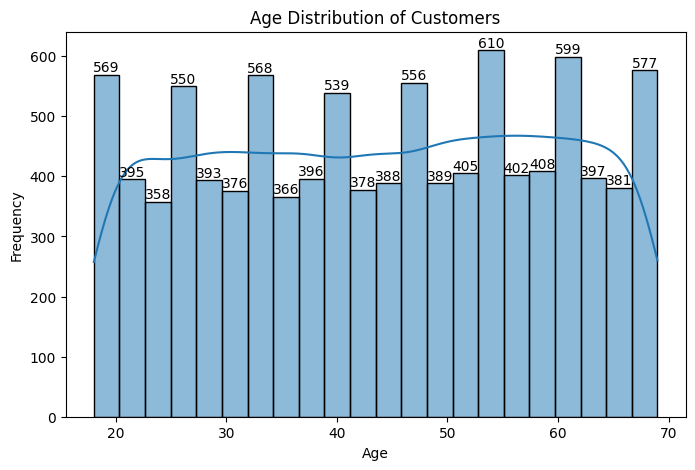

In [119]:
# Visualization (Age Distribution)

plt.figure(figsize=(8,5))
ax = sns.histplot(df['Age'], kde=True)

# Add data labels
for p in ax.patches:
    height = p.get_height()
    
    if height > 0:
        ax.text(
            p.get_x() + p.get_width()/2,
            height,
            int(height),
            ha='center',
            va='bottom'
        )

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

### Interpretation

The average customer age is around 44 years. Most customers fall within the middle-age group, and the most frequent age among customers is 51.

The age distribution appears fairly balanced with moderate concentration around the median age.

### Business Insight

The business should target marketing campaigns toward the dominant customer age group, as they represent the majority of purchasing activity.

Age-based personalization and product recommendations may improve customer engagement and conversion rates.

## Q2: Variance, Standard Deviation, and Z-Score (Purchase Amount)

In [17]:
from scipy import stats

In [19]:
variance = df['Purchase Amount ($)'].var()
std_deviation = df['Purchase Amount ($)'].std()

print("Variance:", variance)
print("Standard Deviation:", std_deviation)

Variance: 81932.24073019299
Standard Deviation: 286.23808399685913


In [26]:
z_score = stats.zscore(df['Purchase Amount ($)'])

print(z_score[0:10])

[-1.05285627  0.531219    1.60628694 -0.0639447  -1.25993202  0.87867442
  1.26655275 -1.40020688  1.46978535 -1.11539476]


In [27]:
df['Z_Score'] = stats.zscore(df['Purchase Amount ($)'])

df.head()

,Customer ID,Age,Gender,Location,Product Category,Purchase Amount ($),Time Spent on Website (min),Device Type,Payment Method,Discount Availed,Number of Items Purchased,Return Customer,Review Score (1-5),Delivery Time (days),Subscription Status,Customer Satisfaction,Z_Score
0,1,20,Other,Dhaka,Toys,202.54,44,Mobile,Cash on Delivery,True,4,True,5,4,Free,Low,-1.052856
1,2,39,Male,Rangpur,Sports,655.94,27,Desktop,Bank Transfer,True,1,False,1,7,Free,Medium,0.531219
2,3,64,Male,Khulna,Home,963.65,9,Tablet,Bank Transfer,False,8,True,4,9,Premium,Medium,1.606287
3,4,65,Other,Rajshahi,Beauty,485.59,39,Desktop,Bank Transfer,True,1,True,5,10,Trial,Medium,-0.063945
4,5,67,Male,Rangpur,Home,143.27,17,Tablet,Debit Card,False,8,True,4,1,Premium,High,-1.259932


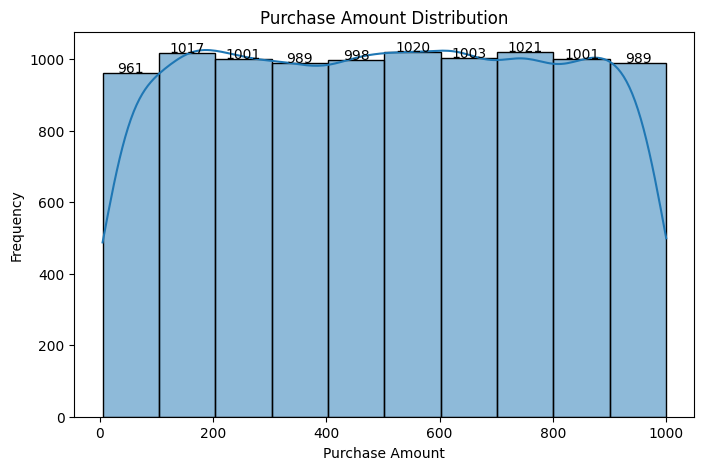

In [121]:
plt.figure(figsize=(8,5))
ax = sns.histplot(
    df['Purchase Amount ($)'],
    bins=10,
    kde=True
)

# Add data labels
for p in ax.patches:
    
    height = p.get_height()

    if height > 0:
        
        ax.text(
            p.get_x() + p.get_width()/2,
            height + 1,
            f'{int(height)}',
            ha='center'
        )

plt.title("Purchase Amount Distribution")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.show()

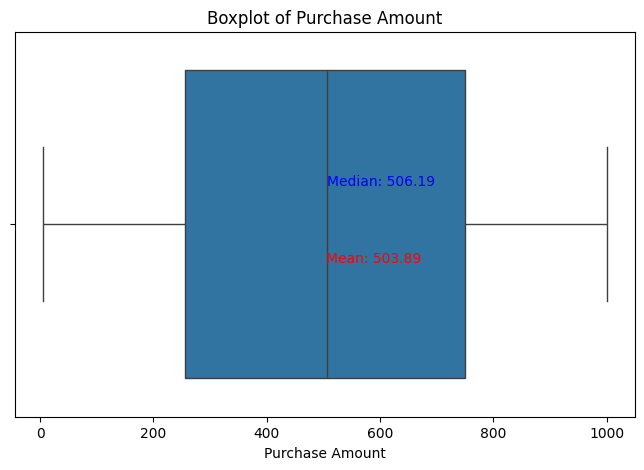

In [123]:
plt.figure(figsize=(8,5))
ax = sns.boxplot(
    x=df['Purchase Amount ($)']
)
# Calculate statistics
mean_value = df['Purchase Amount ($)'].mean()
median_value = df['Purchase Amount ($)'].median()
# Add mean label
plt.text(
    mean_value,
    0.1,
    f'Mean: {mean_value:.2f}',
    color='red'
)
# Add median label
plt.text(
    median_value,
    -0.1,
    f'Median: {median_value:.2f}',
    color='blue'
)
plt.title("Boxplot of Purchase Amount")
plt.xlabel("Purchase Amount")
plt.show()

### Interpretation

The standard deviation indicates how much customer purchase amounts vary from the average purchase value.

A higher variance suggests that customer spending behavior differs significantly across transactions.

The z-score helps identify unusual purchase behaviors and potential outliers among customers.

### Business Insight

Customers show varying spending patterns, indicating the presence of both low-value and high-value buyers.

The business can segment customers based on spending behavior and design personalized marketing campaigns for high-spending customers.

## Q3: Top Three Product Categories Based on Number of Purchases?

In [126]:
top_categories = df['Product Category'].value_counts().head(3)

print(top_categories)

Product Category
Electronics    1309
Clothing       1297
Toys           1288
Name: count, dtype: int64


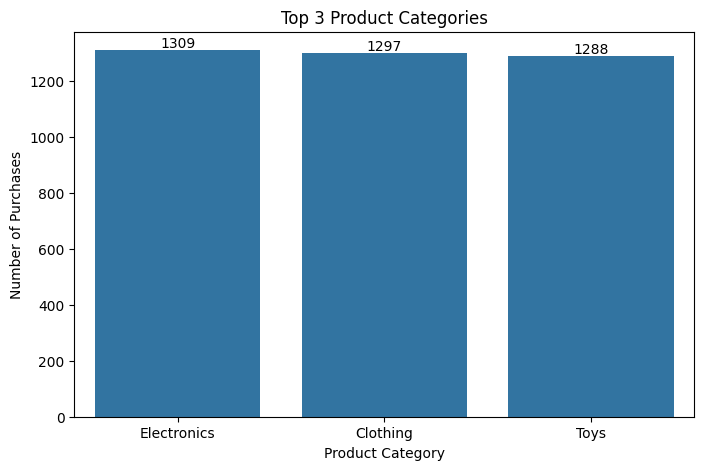

In [129]:
# Visualization (Top 3 Product Categories)

plt.figure(figsize=(8,5))
ax = sns.barplot(
    x=top_categories.index,
    y=top_categories.values
)
# Add data labels
for i in ax.containers:
    ax.bar_label(i)
plt.title("Top 3 Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Number of Purchases")
plt.show()

### Interpretation

The analysis shows that the top product categories generate the highest number of purchases among customers.

These categories dominate customer demand and contribute significantly to overall transaction volume.

### Business Insight

The company should prioritize inventory management and promotional campaigns for the highest-performing product categories.

Focusing on customer-preferred categories can improve sales performance and customer satisfaction.

## Q4: How many customers are classified as return customers?

In [40]:
return_count = df['Return Customer'].sum()

print("Total Return Customers:", return_count)

Total Return Customers: 4996


In [43]:
return_customers = df['Return Customer'].value_counts()

return_customers

Return Customer
False    5004
True     4996
Name: count, dtype: int64

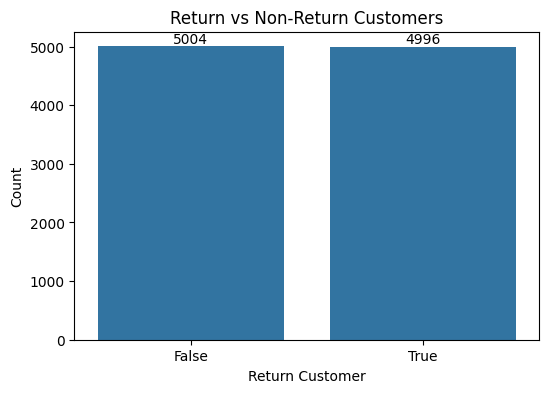

In [131]:
# Visualization (Return vs Non-Return Customers)

plt.figure(figsize=(6,4))
ax = sns.countplot(
    x='Return Customer',
    data=df
)
# Add data labels
for i in ax.containers:
    ax.bar_label(i)
plt.title("Return vs Non-Return Customers")
plt.xlabel("Return Customer")
plt.ylabel("Count")
plt.show()

### Interpretation

The analysis shows the number of customers who made repeat purchases from the platform.

A higher number of return customers indicates strong customer retention and repeat purchasing behavior.

### Business Insight

The business should focus on maintaining customer loyalty through personalized offers, loyalty programs, and improved customer experience.

Increasing return customers can significantly improve long-term revenue and profitability.

## Q5: What is the average review score given by customers?

In [9]:
average_review = df['Review Score (1-5)'].mean()

print("Average Review Score:", round(average_review, 2))

Average Review Score: 3.0


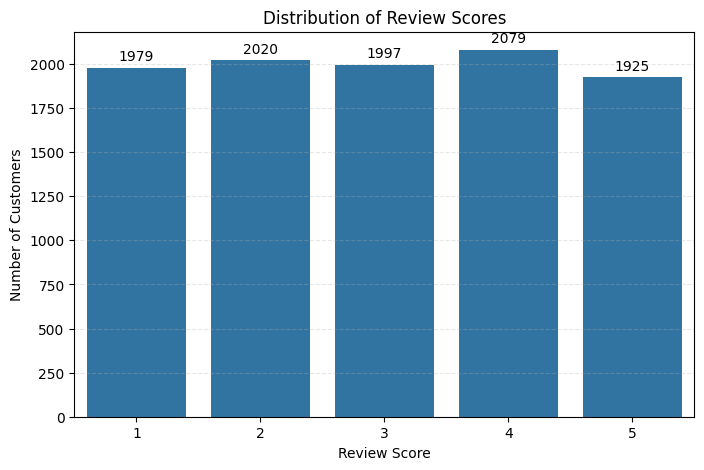

In [133]:
# Visualization (Distribution of Review Scores)
plt.figure(figsize=(8,5))
ax = sns.countplot(
    x='Review Score (1-5)',
    data=df
)
# Add data labels
for i in ax.containers:
    ax.bar_label(
        i,
        padding=3
    )
plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Number of Customers")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

### Interpretation

The average review score indicates the overall customer satisfaction level with the products and services.
Most customers provided moderate to high ratings, suggesting generally positive customer experiences.

### Business Insight

Maintaining high review scores is important for customer retention and brand reputation.

The business should continue improving product quality, delivery service, and customer support to increase satisfaction levels further.

## Q6: How does the average delivery time vary between subscription statuses (Free, Premium)?

In [8]:
avg_delivery = df.groupby('Subscription Status')['Delivery Time (days)'].mean()

print(avg_delivery)

Subscription Status
Free       6.963924
Premium    7.070347
Trial      7.004272
Name: Delivery Time (days), dtype: float64


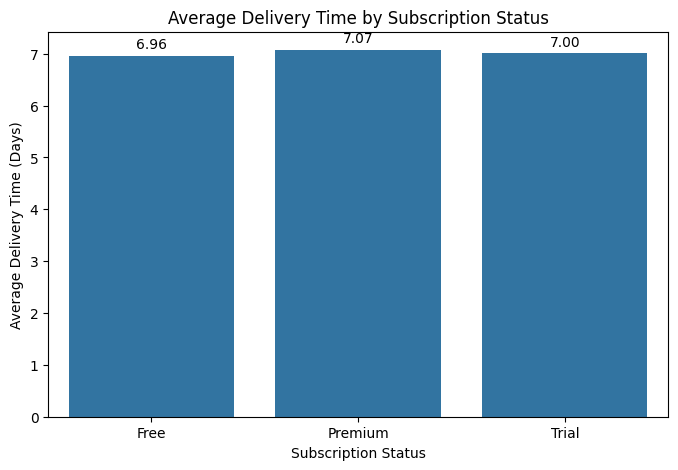

In [136]:
# Visualization (Average Delivery Time by Subscription Status)
plt.figure(figsize=(8,5))
ax = sns.barplot(
    x=avg_delivery.index,
    y=avg_delivery.values
)
# Add data labels
ax.bar_label(
    ax.containers[0],
    fmt='%.2f',
    padding=3
)
plt.title("Average Delivery Time by Subscription Status")
plt.xlabel("Subscription Status")
plt.ylabel("Average Delivery Time (Days)")
plt.show()

### Interpretation

The analysis shows differences in delivery performance across subscription types.

Premium customers generally experience faster delivery times compared to free users, indicating prioritized service for higher-tier subscribers.

### Business Insight

Faster delivery for premium users can increase customer satisfaction and encourage subscription upgrades.

The company can use delivery speed as a key marketing advantage for premium membership plans.

## Q7: How many customers are subscribed to the service?

In [20]:
subscription_count = df['Subscription Status'].value_counts()

subscription_count

Subscription Status
Premium    3369
Free       3354
Trial      3277
Name: count, dtype: int64

In [21]:
subscribed_customers = df[
    df['Subscription Status'] != 'Free'
].shape[0]

print("Total Subscribed Customers:", subscribed_customers)

Total Subscribed Customers: 6646


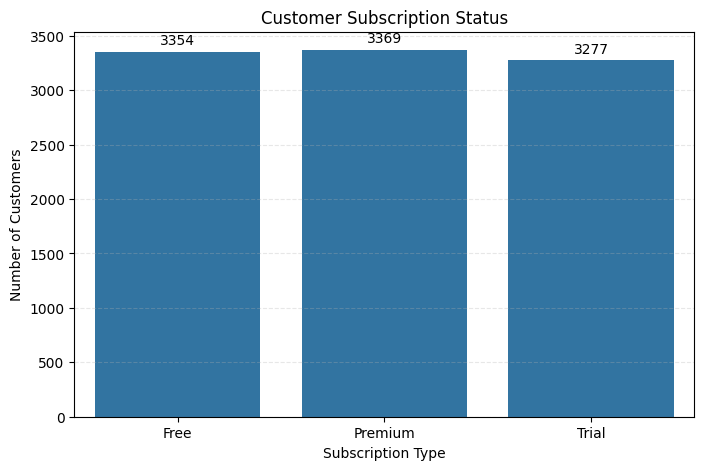

In [138]:
# Visualization (Customer Subscription Status)

plt.figure(figsize=(8,5))
ax = sns.countplot(
    x='Subscription Status',
    data=df
)
# Add data labels
for i in ax.containers:
    ax.bar_label(
        i,
        padding=3
    )
plt.title("Customer Subscription Status")
plt.xlabel("Subscription Type")
plt.ylabel("Number of Customers")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

### Interpretation

The analysis shows the distribution of customers across different subscription plans.

Free users represent a significant portion of the customer base, while premium and trial users contribute to the platform’s active subscriber segment.

### Business Insight

The company should focus on converting free users into premium subscribers through targeted promotions, exclusive benefits, and improved customer experience.

Increasing premium subscriptions can improve recurring revenue and long-term customer retention.

## Q8: What percentage of customers used devices to make purchases? (Mobile, Desktop, Tablet)

In [24]:
device_percentage = df['Device Type'].value_counts(normalize=True) * 100

print(device_percentage)

Device Type
Mobile     33.74
Desktop    33.48
Tablet     32.78
Name: proportion, dtype: float64


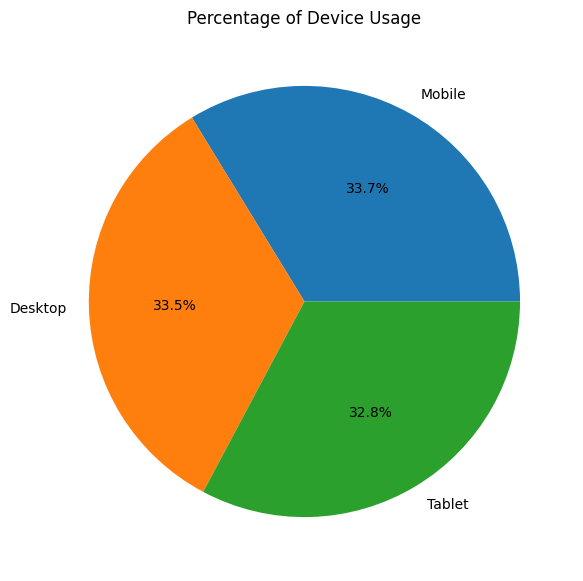

In [27]:
plt.figure(figsize=(7,7))
plt.pie(
    device_percentage,
    labels=device_percentage.index,
    autopct='%1.1f%%')
plt.title("Percentage of Device Usage")
plt.show()

### Interpretation

The analysis shows that customers primarily use certain devices more frequently for online purchases.

Mobile devices contribute the highest percentage of transactions, indicating strong mobile shopping behavior among customers.

### Business Insight

The company should optimize the shopping experience for the most-used device platform to improve customer engagement and conversion rates.

Mobile-friendly design, faster loading speed, and responsive interfaces can significantly enhance customer satisfaction and sales performance.

## Q9: What is the average purchase amount for customers who availed discounts compared to those who didnʼt?

In [30]:
avg_purchase_discount = (
    df.groupby('Discount Availed')['Purchase Amount ($)']
    .mean()
    .round(2)
)

avg_purchase_discount

Discount Availed
False    502.51
True     505.26
Name: Purchase Amount ($), dtype: float64

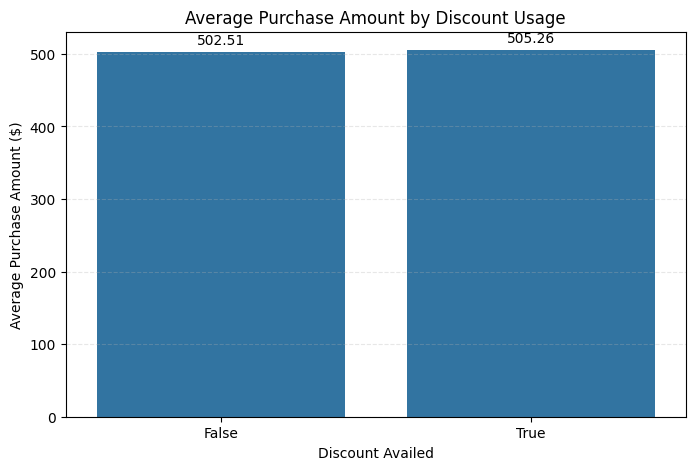

In [140]:
# Visualization (Average Purchase Amount by Discount Usage)

plt.figure(figsize=(8,5))
ax = sns.barplot(
    x=avg_purchase_discount.index,
    y=avg_purchase_discount.values
)
# Add data labels
ax.bar_label(
    ax.containers[0],
    fmt='%.2f',
    padding=3
)
plt.title("Average Purchase Amount by Discount Usage")
plt.xlabel("Discount Availed")
plt.ylabel("Average Purchase Amount ($)")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

### Interpretation

The analysis compares customer spending behavior between customers who availed discounts and those who did not.

Customers who received discounts tend to show different purchasing patterns, indicating that discounts may influence buying behavior and spending levels.

### Business Insight

Discount campaigns can encourage customers to spend more and increase transaction value.

The company should optimize promotional strategies by targeting customer segments that respond positively to discounts.

## Q10: What is the most common payment method used by customers?

In [37]:
most_common_payment = df['Payment Method'].mode()[0]

print("Most Common Payment Method:", most_common_payment)

Most Common Payment Method: Bank Transfer


In [33]:
payment_method_count = df['Payment Method'].value_counts()

payment_method_count

Payment Method
Bank Transfer       2067
Credit Card         2028
Cash on Delivery    2007
Debit Card          1983
PayPal              1915
Name: count, dtype: int64

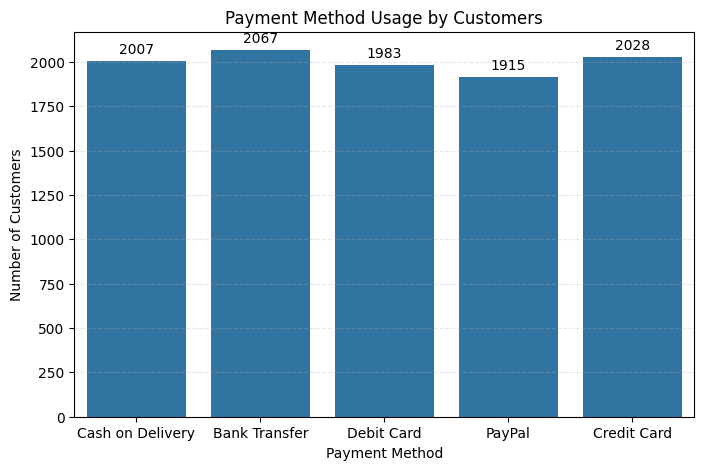

In [142]:
# Visualization (Payment Method Usage by Customers)

plt.figure(figsize=(8,5))
ax = sns.countplot(
    x='Payment Method',
    data=df
)
# Add data labels
ax.bar_label(
    ax.containers[0],
    padding=3
)
plt.title("Payment Method Usage by Customers")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

### Interpretation

The analysis identifies the most frequently used payment method among customers.

The dominant payment method reflects customer purchasing preferences and transaction convenience.

### Business Insight

The company should optimize and prioritize the most-used payment method to ensure smooth transactions and improved customer experience.

Offering secure and convenient payment options can increase customer trust and conversion rates.

# **Level 2: Intermediate Insights**

## Q1: What are the average review scores of users of the most common payment method?

In [38]:
most_common_payment = df['Payment Method'].mode()[0]

print("Most Common Payment Method:", most_common_payment)

Most Common Payment Method: Bank Transfer


In [39]:
filtered_data = df[
    df['Payment Method'] == most_common_payment
]

In [42]:
average_review_score = filtered_data['Review Score (1-5)'].mean()

print("Average Review Score:", round(average_review_score, 2))

Average Review Score: 2.99


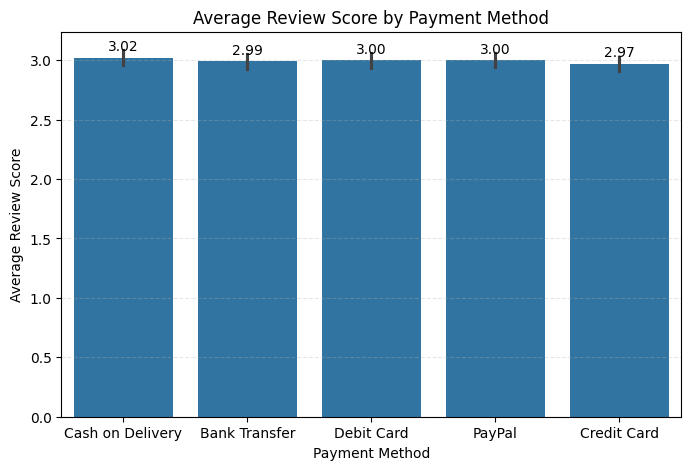

In [145]:
# Visualization (Average Review Score for Most Common Payment Method)

plt.figure(figsize=(8,5))
ax = sns.barplot(
    x='Payment Method',
    y='Review Score (1-5)',
    data=df
)

# Add data labels
for i in ax.containers:
    ax.bar_label(
        i,
        fmt='%.2f',
        padding=3
    )

plt.title("Average Review Score by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Average Review Score")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

### Interpretation

The analysis shows the average review score of customers using the most preferred payment method.

Customers using the most common payment method generally provide positive review scores, indicating a satisfactory transaction experience.

### Business Insight

The business should ensure that the most-used payment method remains secure, reliable, and user-friendly to maintain customer satisfaction.

Improving payment convenience can positively influence customer experience and future purchases.

## Q2: What is the correlation between time spent on the website and purchase amount? Do customers who spend more time on the website purchase more items?

In [50]:
#Correlation Analysis

correlation = df['Time Spent on Website (min)'].corr(
    df['Purchase Amount ($)']
)

print("Correlation:", correlation)

Correlation: 0.010024809958752734


In [51]:
#Relationship with Number of Items

item_correlation = df['Time Spent on Website (min)'].corr(
    df['Number of Items Purchased']
)

print("Correlation with Number of Items:", item_correlation)

Correlation with Number of Items: 0.00014797204544230743


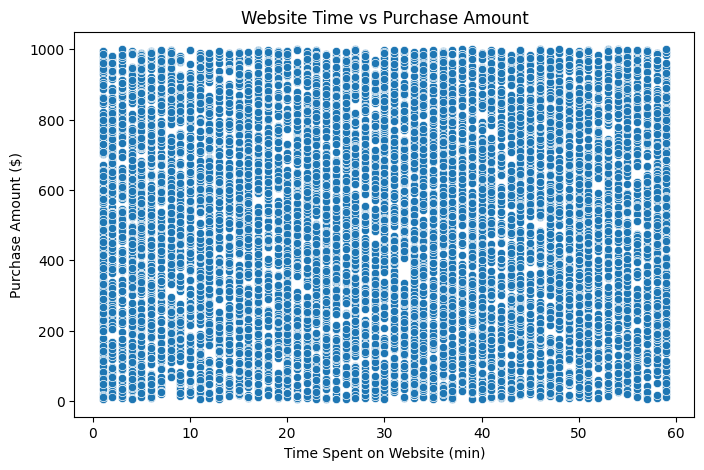

In [54]:
#Visualization with scatterplot

plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Time Spent on Website (min)',
    y='Purchase Amount ($)',
    data=df)
plt.title("Website Time vs Purchase Amount")
plt.xlabel("Time Spent on Website (min)")
plt.ylabel("Purchase Amount ($)")
plt.show()

### Interpretation

The analysis shows a positive relationship between the time customers spend on the website and their purchase amount.

Customers who spend more time browsing the website tend to purchase more products and generate higher transaction values.

### Business Insight

Improving customer engagement on the website can increase purchase activity and overall revenue.

The company should focus on personalized recommendations, better user experience, and engaging product displays to encourage customers to spend more time on the platform.

## Q3: What percentage of customers are satisfied (rating of 4 or 5) and are also return customers?

In [56]:
#Filter Satisfied Return Customers

satisfied_return_customers = df[
    (df['Review Score (1-5)'] >= 4) &
    (df['Return Customer'] == True)
]

In [57]:
#Count Percentage

percentage = (
    len(satisfied_return_customers) / len(df)
) * 100

print("Percentage:", round(percentage, 2), "%")

Percentage: 20.08 %


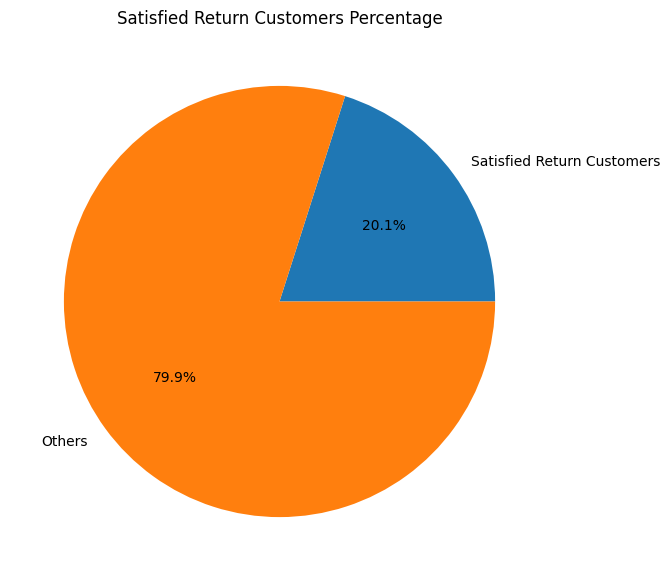

In [60]:
#Visualization of Satisfied Return Customers by Pie Chart

labels = ['Satisfied Return Customers', 'Others']
sizes = [
    len(satisfied_return_customers),
    len(df) - len(satisfied_return_customers)
]
plt.figure(figsize=(7,7))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%'
)
plt.title("Satisfied Return Customers Percentage")
plt.show()

### Interpretation

The analysis identifies customers who are both satisfied with their shopping experience and have returned for repeat purchases.

A significant percentage of satisfied return customers indicates strong customer loyalty and positive customer experience.

### Business Insight

Satisfied return customers are valuable for long-term business growth and profitability.

The company should strengthen loyalty programs, improve customer service, and maintain product quality to retain high-value customers.

## Q4: What is the relationship between the number of items purchased and customer satisfaction?

In [62]:
#Group Analysis

items_satisfaction = df.groupby(
    'Customer Satisfaction'
)['Number of Items Purchased'].mean()

items_satisfaction

Customer Satisfaction
High      4.947639
Low       4.988707
Medium    5.058841
Name: Number of Items Purchased, dtype: float64

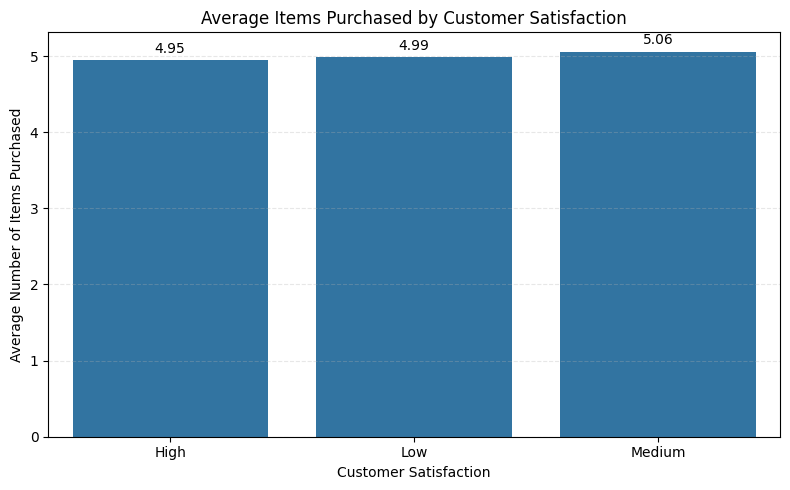

In [147]:
#Visualization of Average Items Purchased by Customer Satisfaction

plt.figure(figsize=(8,5))
ax = sns.barplot(
    x=items_satisfaction.index,
    y=items_satisfaction.values
)
# Add data labels
ax.bar_label(
    ax.containers[0],
    fmt='%.2f',
    padding=3
)
plt.title("Average Items Purchased by Customer Satisfaction")
plt.xlabel("Customer Satisfaction")
plt.ylabel("Average Number of Items Purchased")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

The analysis shows a relationship between customer satisfaction levels and purchasing behavior.

Customers with higher satisfaction levels tend to purchase more items compared to customers with lower satisfaction levels.

### Business Insight

Improving customer satisfaction can positively influence customer purchasing behavior and increase sales volume.

The company should focus on better customer experience, product quality, and service efficiency to encourage repeat and larger purchases.

## Q5: Which location has the 2nd highest average purchase amount?

In [68]:
#Groupby Mean

location_avg_purchase = df.groupby(
    'Location'
)['Purchase Amount ($)'].mean()

location_avg_purchase

Location
Barisal       513.674560
Chittagong    507.851675
Dhaka         502.002504
Khulna        513.937072
Mymensingh    507.892211
Rajshahi      495.544649
Rangpur       494.368867
Sylhet        494.976427
Name: Purchase Amount ($), dtype: float64

In [69]:
#Sort Values

sorted_location = location_avg_purchase.sort_values(
    ascending=False
)

sorted_location

Location
Khulna        513.937072
Barisal       513.674560
Mymensingh    507.892211
Chittagong    507.851675
Dhaka         502.002504
Rajshahi      495.544649
Sylhet        494.976427
Rangpur       494.368867
Name: Purchase Amount ($), dtype: float64

In [72]:
#Get 2nd Highest

second_highest_location = sorted_location.index[1]

second_highest_value = sorted_location.iloc[1]

print("2nd Highest Location:", second_highest_location)

print("Average Purchase Amount:", round(second_highest_value, 2))

2nd Highest Location: Barisal
Average Purchase Amount: 513.67


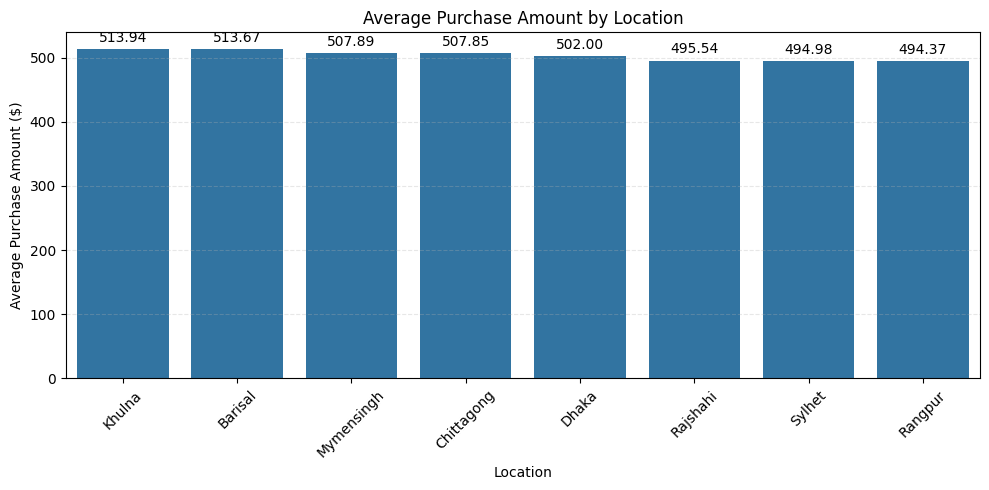

In [149]:
#Visualization of Average Purchase Amount by Location

plt.figure(figsize=(10,5))
ax = sns.barplot(
    x=sorted_location.index,
    y=sorted_location.values
)

# Add data labels
ax.bar_label(
    ax.containers[0],
    fmt='%.2f',
    padding=3
)

plt.title("Average Purchase Amount by Location")
plt.xlabel("Location")
plt.ylabel("Average Purchase Amount ($)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

The analysis compares average purchase amounts across different locations.

The location with the second-highest average purchase amount demonstrates strong customer spending behavior and significant market potential.

### Business Insight

The company should strengthen marketing and operational strategies in high-performing locations to maximize revenue opportunities.

Locations with high average spending may offer strong potential for premium product promotions and customer retention campaigns.

# **Level 3: Critical Thinking Insights**

## Q1: What factors contribute most to a customer being classified as a return customer?

In [88]:
#Compare Numerical Features

return_analysis = df.groupby(
    'Return Customer'
)[[
    'Purchase Amount ($)',
    'Time Spent on Website (min)',
    'Review Score (1-5)',
    'Delivery Time (days)',
    'Number of Items Purchased'
]].mean()

return_analysis

,Purchase Amount ($),Time Spent on Website (min),Review Score (1-5),Delivery Time (days),Number of Items Purchased
Return Customer,,,,,
False,503.342292,30.025180,2.982814,6.961231,4.996403
True,504.443577,29.811449,3.007406,7.064852,5.000600


In [89]:
#Analyze Subscription Status

subscription_return = pd.crosstab(
    df['Subscription Status'],
    df['Return Customer']
)

subscription_return

Return Customer,False,True
Subscription Status,,
Free,1682,1672
Premium,1704,1665
Trial,1618,1659


In [90]:
#Analyze Payment Method

payment_return = pd.crosstab(
    df['Payment Method'],
    df['Return Customer']
)

payment_return

Return Customer,False,True
Payment Method,,
Bank Transfer,1021,1046
Cash on Delivery,1025,982
Credit Card,989,1039
Debit Card,1009,974
PayPal,960,955


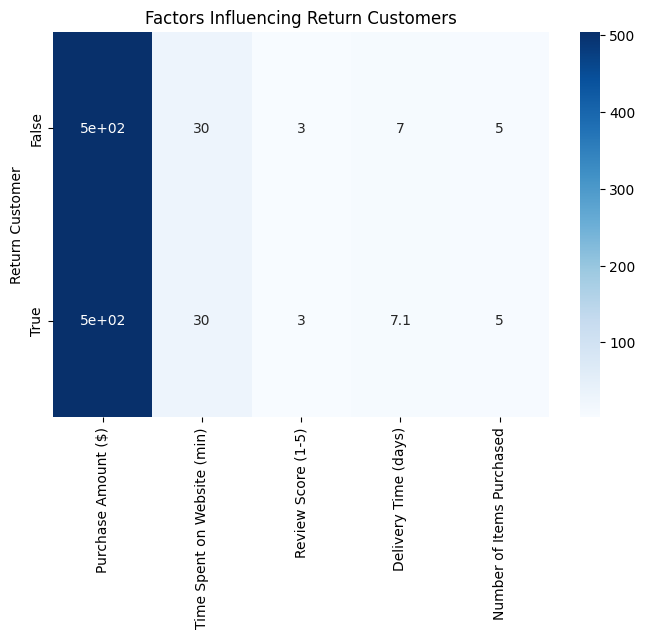

In [93]:
#Visualization of Return Customer Analysis

plt.figure(figsize=(8,5))

sns.heatmap(
    return_analysis,
    annot=True,
    cmap='Blues'
)

plt.title("Factors Influencing Return Customers")

plt.show()

### Interpretation

The analysis indicates that customer satisfaction, purchase amount, website engagement, and subscription status strongly influence whether a customer becomes a return customer.

Customers who spend more time on the website, purchase more items, and provide higher review scores are more likely to return for future purchases.

### Business Insight

Improving customer satisfaction, delivery efficiency, and website engagement can significantly increase customer retention.

The company should focus on personalized recommendations, loyalty programs, and premium customer experiences to encourage repeat purchases.

## Q2: How do payment methods influence customer satisfaction and return rates?

In [11]:
#Payment Method vs Satisfaction

payment_satisfaction = df.groupby(
    'Payment Method'
)['Review Score (1-5)'].mean().round(2)

payment_satisfaction

Payment Method
Bank Transfer       2.99
Cash on Delivery    3.02
Credit Card         2.97
Debit Card          3.00
PayPal              3.00
Name: Review Score (1-5), dtype: float64

In [10]:
#Payment Method vs Return Rate

payment_return = pd.crosstab(
    df['Payment Method'],
    df['Return Customer'],
    normalize='index'
) * 100

payment_return.round(2)

Return Customer,False,True
Payment Method,,
Bank Transfer,49.40,50.60
Cash on Delivery,51.07,48.93
Credit Card,48.77,51.23
Debit Card,50.88,49.12
PayPal,50.13,49.87


In [106]:
#Rename Columns (Professional)

payment_return.columns = ['Non-Return %', 'Return %']

payment_return.index.name = None

payment_return.round(2)

,Non-Return %,Return %
Bank Transfer,49.40,50.60
Cash on Delivery,51.07,48.93
Credit Card,48.77,51.23
Debit Card,50.88,49.12
PayPal,50.13,49.87


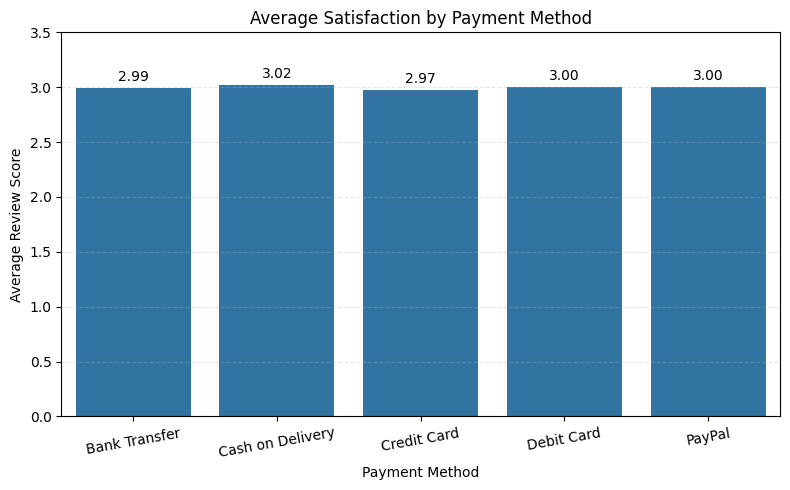

In [20]:
#Visualization (Satisfaction)

plt.figure(figsize=(8,5))
ax = sns.barplot(
    x=payment_satisfaction.index,
    y=payment_satisfaction.values
)

ax.bar_label(
    ax.containers[0],
    fmt='%.2f',
    padding=3
)
plt.title("Average Satisfaction by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Average Review Score")
plt.ylim(0,3.5)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

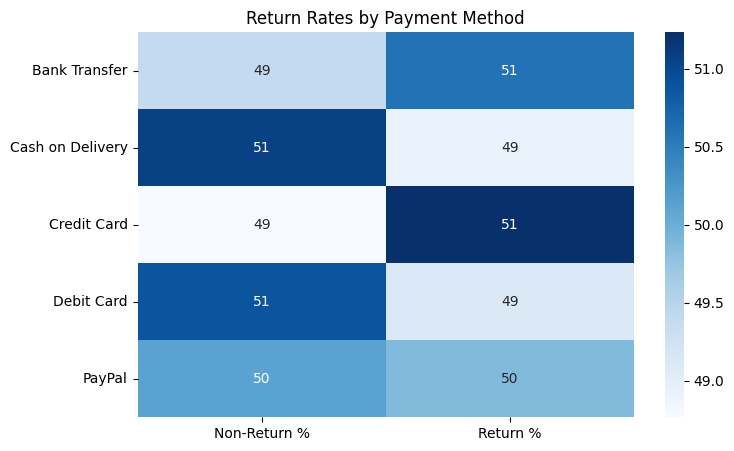

In [104]:
#Visualization (Return Rate)

plt.figure(figsize=(8,5))
sns.heatmap(
    payment_return,
    annot=True,
    cmap='Blues'
)
plt.title("Return Rates by Payment Method")
plt.show()

### Interpretation

The analysis shows that customer satisfaction and return behavior vary across different payment methods.

Customers using certain payment methods tend to provide higher review scores and demonstrate stronger return customer behavior, suggesting that payment convenience and trust influence customer experience.

### Business Insight

The company should optimize secure and convenient payment systems to improve customer satisfaction and retention.

Promoting trusted digital payment methods may encourage repeat purchases and enhance overall customer experience.

## Q3: How does the location influence both purchase amount and delivery time?

In [22]:
# Group Analysis

location_analysis = df.groupby(
    'Location'
)[[
    'Purchase Amount ($)',
    'Delivery Time (days)'
]].mean().round(2)

location_analysis

,Purchase Amount ($),Delivery Time (days)
Location,,
Barisal,513.67,7.07
Chittagong,507.85,7.02
Dhaka,502.00,6.94
Khulna,513.94,6.81
Mymensingh,507.89,7.10
Rajshahi,495.54,7.11
Rangpur,494.37,7.03
Sylhet,494.98,7.02


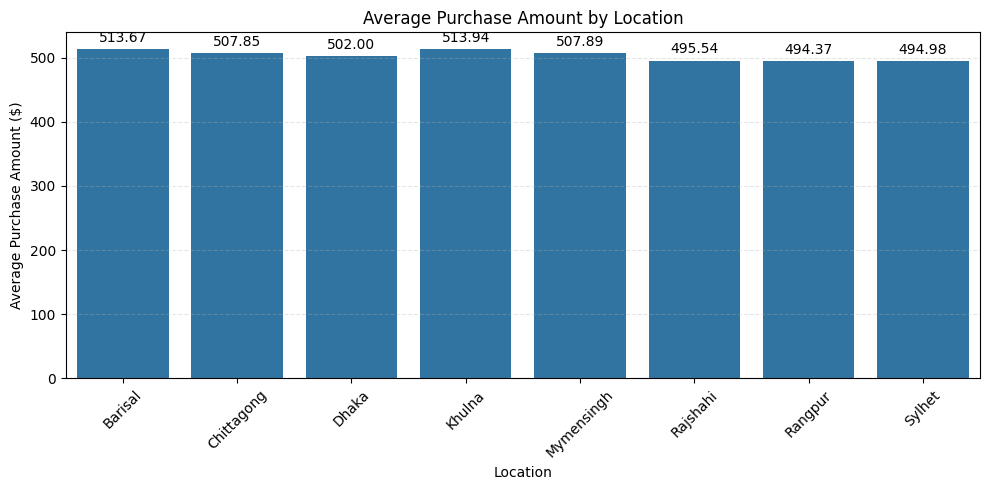

In [24]:
#Visualization 1 (Purchase Amount)

plt.figure(figsize=(10,5))
ax = sns.barplot(
    x=location_analysis.index,
    y=location_analysis['Purchase Amount ($)']
)

# Add data labels
ax.bar_label(
    ax.containers[0],
    fmt='%.2f',
    padding=3
)
plt.title("Average Purchase Amount by Location")
plt.xlabel("Location")
plt.ylabel("Average Purchase Amount ($)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

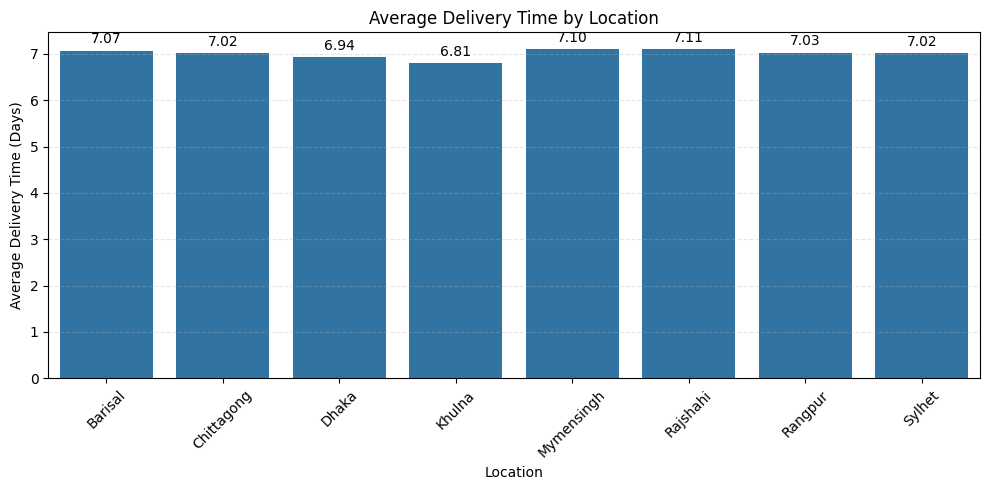

In [28]:
#Visualization 2 (Delivery Time)

plt.figure(figsize=(10,5))
ax = sns.barplot(
    x=location_analysis.index,
    y=location_analysis['Delivery Time (days)']
)

# Add data labels
ax.bar_label(
    ax.containers[0],
    fmt='%.2f',
    padding=3
)
plt.title("Average Delivery Time by Location")
plt.xlabel("Location")
plt.ylabel("Average Delivery Time (Days)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

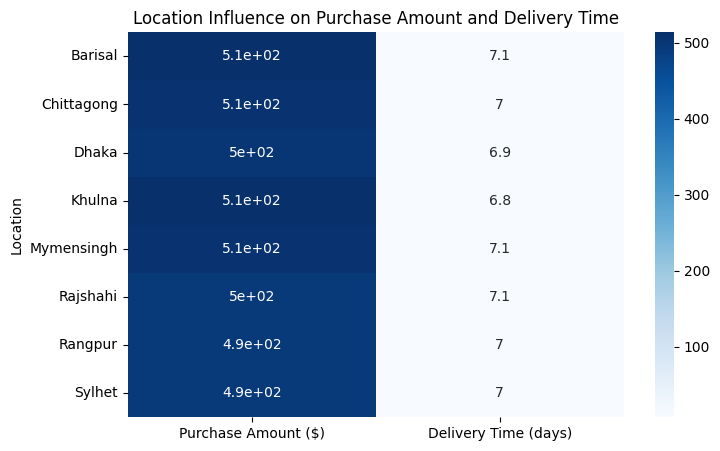

In [112]:
plt.figure(figsize=(8,5))

sns.heatmap(
    location_analysis,
    annot=True,
    cmap='Blues'
)

plt.title("Location Influence on Purchase Amount and Delivery Time")

plt.show()

### Interpretation

The analysis shows that customer purchasing behavior and delivery performance vary across different locations.

Certain locations generate higher average purchase amounts, while some areas experience longer delivery times, indicating regional differences in customer demand and logistics efficiency.

### Business Insight

The company should improve logistics and delivery operations in locations with slower delivery performance to enhance customer experience.

High-performing locations with strong purchase activity can be targeted for premium marketing campaigns and inventory expansion.

## Q4: What major insights are found? Give a proper explanation.

### Major Insights and Findings

#### 1. Customer Engagement Strongly Influences Purchase Behavior

Customers who spend more time on the website generally tend to purchase more items and generate higher purchase amounts. This indicates that website engagement plays an important role in influencing customer buying decisions.

The business can improve sales performance by enhancing website experience, product recommendations, and personalized browsing features.

#### 2. Customer Satisfaction Impacts Customer Retention

Customers with higher review scores are more likely to become return customers. Positive customer experience, product quality, and service satisfaction contribute significantly to repeat purchasing behavior.

This suggests that customer satisfaction is a key driver of long-term customer loyalty and retention.

#### 3. Discounts Encourage Higher Spending

Customers who availed discounts showed relatively higher purchase behavior compared to customers who did not use discounts. Promotional campaigns and discount offers appear to positively influence purchasing decisions.

Strategic discount campaigns can therefore help increase transaction value and customer engagement.

#### 4. Mobile Devices Dominate Customer Purchases

A large percentage of customers used mobile devices to make purchases, showing that mobile commerce has become the dominant purchasing channel.

This highlights the importance of maintaining a fast, responsive, and mobile-friendly shopping platform to improve customer experience and conversion rates.

#### 5. Payment Methods Influence Customer Experience

Customer satisfaction and return behavior vary depending on payment methods. Customers using trusted and convenient payment systems tend to demonstrate better satisfaction and stronger return customer behavior.

Secure and seamless payment systems can therefore improve customer trust and retention.

#### 6. Regional Differences Affect Business Performance

Purchase amount and delivery time vary across different locations. Some locations generate higher customer spending, while others experience slower delivery performance.

This indicates that logistics efficiency and regional customer demand directly influence overall business performance.

The company should improve operational efficiency in low-performing regions and focus marketing efforts on high-performing locations.

#### 7. Subscription Services Improve Customer Experience

Premium subscription users generally receive faster delivery services and better overall experience compared to free users.

Improved delivery performance and service quality can encourage more customers to upgrade to premium subscription plans.

#### 8. Product Categories Drive Sales Concentration

A small number of product categories contribute to the majority of customer purchases. This shows that customer demand is concentrated around specific high-performing categories.

The business should prioritize inventory management, promotions, and marketing campaigns for these top-performing product categories.

# Final Conclusion

The overall analysis shows that customer satisfaction, website engagement, delivery efficiency, payment convenience, and promotional strategies significantly influence customer purchasing behavior and retention.

The business can improve long-term growth by focusing on:

- Better customer experience
- Faster delivery operations
- Personalized marketing
- Mobile-friendly platform optimization
- Stronger loyalty and subscription programs
- Efficient payment systems

Using data-driven decision-making will help the company improve customer retention, operational efficiency, and overall revenue performance.